(chap_aihc_deep_learning)=
# Deep Learning and Neural Networks for Healthcare

**A weak-to-strong model ladder on official DermaMNIST**

Deep learning is most useful when we can explain what capability it adds beyond simpler alternatives. This tutorial therefore builds five multiclass image classifiers in a deliberate sequence:

$$
\text{class prior} \rightarrow \text{coarse colour/texture logistic}
\rightarrow \text{pixel logistic} \rightarrow \text{MLP} \rightarrow \text{CNN}.
$$

## At a glance

| Item | This tutorial |
|---|---|
| **Question** | How much do learned spatial representations add when classifying seven DermaMNIST categories? |
| **Data** | Official DermaMNIST, derived from HAM10000: 7,007 training, 1,003 validation, and 2,005 test images; RGB; $28\times28$ pixels |
| **Model ladder** | Training prior, seven global colour/contrast features + multinomial logistic regression, PCA-compressed flattened-pixel logistic regression, compact MLP, compact CNN |
| **Selection rule** | Regularization and neural-network epochs use validation macro AUPRC only; the test set is opened after choices are frozen |
| **Metrics** | Balanced accuracy, macro F1, macro one-vs-rest AUROC and AUPRC, multiclass log loss, confusion matrix, per-class recall/AP |
| **Runtime** | Usually 2–4 minutes on a Colab CPU; faster with a GPU |
| **Core route** | Sections 1–13, including the final comparison, take about 30–35 minutes; later sections are optional depth |

### Learning objectives

By the end, you should be able to:

1. explain why ordinary accuracy is misleading for an imbalanced multiclass dataset;
2. distinguish information added by engineered summaries, pixels, nonlinearity, and convolution;
3. trace the shapes of RGB image tensors through an MLP and CNN;
4. use a validation split without repeatedly optimizing against the test set;
5. calculate macro one-vs-rest ranking metrics without inventing a binary threshold; and
6. interpret moderate, non-monotonic performance as evidence rather than a model leaderboard.

:::{admonition} Educational scope
:class: warning
This notebook is not a skin-lesion diagnostic system. Do not use its predictions for patient care. It does not validate clinical workflow, external sites, acquisition devices, demographic groups, reader comparison, prospective outcomes, or regulatory requirements.
:::


## 1. What does each rung add?

A weak-to-strong ladder should not merely add parameters. Each step should answer a different scientific question.

| Model | Input | New capability | What remains impossible or difficult |
|---|---|---|---|
| Class prior | training labels only | reflects class prevalence | cannot distinguish two images |
| Global logistic | RGB means, RGB standard deviations, overall intensity variation | linear use of coarse colour and texture/contrast | discards lesion location, border, and local pattern |
| Pixel logistic | a linear projection of all 2,352 RGB pixels | uses spatially indexed pixel information | cannot form nonlinear or hierarchical patterns |
| MLP | all flattened pixels | nonlinear interactions between any pixels | flattening does not explicitly preserve neighbourhood structure |
| CNN | the 2-D RGB grid | shared local filters and hierarchical spatial representation | can still exploit shortcuts and remain poorly calibrated or non-transportable |

“Stronger” refers to representation capacity and a better-matched inductive bias. It does **not** promise that every metric increases at every step. A well-chosen coarse feature can beat a poorly optimized neural model; a larger model can overfit; and macro metrics can move differently because rare classes receive equal weight.


## 2. Dataset provenance and why the task is difficult

DermaMNIST is a $28\times28$ version of images from HAM10000, a collection of dermatoscopic images from multiple sources. MedMNIST provides a standardized seven-class task and official 70%/10%/20% train/validation/test split. The classes include melanocytic nevi, melanoma, basal cell carcinoma, vascular lesions, and several other lesion groups.

The dataset is attractive for education because it is small enough to download and train in Colab. Its limitations are equally important:

- downsampling from the source resolution removes substantial visual detail;
- classes are highly imbalanced, with melanocytic nevi forming most examples;
- HAM10000 contains multiple images of some lesions, so an image-level split can be more optimistic than a patient- or lesion-level external evaluation;
- diagnostic labels have different verification routes and may inherit uncertainty;
- dermatoscopic acquisition is not the same as every real primary-care or patient-facing setting; and
- benchmark performance does not measure how a model changes clinical decisions or outcomes.

:::{admonition} Result disclaimer
:class: important
The reported values apply only to these official internal benchmark splits and this implementation. Even a high macro AUROC would not establish clinical accuracy: one-vs-rest AUROC can look encouraging while rare-class precision, calibration, or argmax classification remains modest. MedMNIST explicitly states that it is not intended for clinical use.
:::


## 3. Reproducible setup and official-data-only loading

The setup cell installs MedMNIST only if needed. The following loader requests `DermaMNIST` from the package and stops with an actionable error if the official archive cannot be obtained. It never manufactures images or silently switches datasets.

We use a visible local cache so repeated Colab runs do not redownload the archive. Random seeds make CPU runs reproducible; exact GPU kernels can still differ slightly.


In [1]:
# Phase 1: install the official dataset interface only when the runtime needs it.
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("medmnist") is None:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", "medmnist==3.0.2"]
    )

# Phase 2: import numerical, plotting, classical-ML, and neural-network tools.
import copy
import random
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
# Some locked-down runtimes cannot create MedMNIST's optional default cache;
# this tutorial supplies an explicit writable cache in the next cell.
warnings.filterwarnings("ignore", message="Failed to setup default root.*")
import medmnist
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from medmnist import INFO
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    log_loss,
    roc_auc_score,
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, label_binarize
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

# Phase 3: seed every source of randomness used below.
SEED = 17
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(min(2, torch.get_num_threads()))
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch {torch.__version__}; training device: {DEVICE}")


KeyboardInterrupt: 

In [ ]:
DATA_FLAG = "dermamnist"
dataset_info = INFO[DATA_FLAG]
DatasetClass = getattr(medmnist, dataset_info["python_class"])
data_root = Path("data/medmnist")
data_root.mkdir(parents=True, exist_ok=True)

try:
    # Phase 1: request each published split without merging or resplitting it.
    train_dataset = DatasetClass(split="train", root=str(data_root), download=True, size=28)
    val_dataset = DatasetClass(split="val", root=str(data_root), download=True, size=28)
    test_dataset = DatasetClass(split="test", root=str(data_root), download=True, size=28)
except Exception as exc:
    # Phase 2: fail visibly; changing the dataset would change the scientific task.
    raise RuntimeError(
        "Official DermaMNIST could not be loaded. This notebook intentionally uses "
        "no substitute data. Enable internet access in Colab and rerun. Original error: "
        + str(exc)
    ) from exc

# Phase 3: display provenance beside the run rather than relying on memory.
print("Dataset description:", dataset_info["description"])
print("Licence:", dataset_info["license"])
print("Official label map:", dataset_info["label"])
print("Official split sizes:", dataset_info["n_samples"])


Dataset description: The DermaMNIST is based on the HAM10000, a large collection of multi-source dermatoscopic images of common pigmented skin lesions. The dataset consists of 10,015 dermatoscopic images categorized as 7 different diseases, formulized as a multi-class classification task. We split the images into training, validation and test set with a ratio of 7:1:2. The source images of 3×600×450 are resized into 3×28×28.
Licence: CC BY-NC 4.0
Official label map: {'0': 'actinic keratoses and intraepithelial carcinoma', '1': 'basal cell carcinoma', '2': 'benign keratosis-like lesions', '3': 'dermatofibroma', '4': 'melanoma', '5': 'melanocytic nevi', '6': 'vascular lesions'}
Official split sizes: {'train': 7007, 'val': 1003, 'test': 2005}


## 4. Convert the package arrays and audit the class distribution

MedMNIST stores RGB images as `[image, height, width, channel]` with integer values from 0 to 255. We divide by 255 to obtain floating-point values from 0 to 1. This fixed unit conversion does not estimate anything from held-out data.

Labels are converted from shape `[N, 1]` to `[N]`. We preserve the official splits exactly. The assertions are not cosmetic: they make the expected dataset version, shape, channels, and label set executable.


In [ ]:
def medmnist_arrays(dataset):
    '''Convert one official split to images [N,28,28,3] and labels [N].'''
    # Phase 1: use the package's verified in-memory archive rather than PIL loops.
    images = dataset.imgs.astype(np.float32) / 255.0
    labels = dataset.labels.reshape(-1).astype(np.int64)
    # Phase 2: return independent arrays without learning preprocessing statistics.
    return images, labels


X_train, y_train = medmnist_arrays(train_dataset)
X_val, y_val = medmnist_arrays(val_dataset)
X_test, y_test = medmnist_arrays(test_dataset)
CLASS_NAMES = [dataset_info["label"][str(index)] for index in range(7)]
N_CLASSES = len(CLASS_NAMES)

# Phase 3: fail early if the active archive differs from the documented task.
assert X_train.shape == (7007, 28, 28, 3)
assert X_val.shape == (1003, 28, 28, 3)
assert X_test.shape == (2005, 28, 28, 3)
assert set(np.unique(y_train)) == set(range(N_CLASSES))

# Test images are loaded for later inference, but their labels are not summarized here.
split_summary = pd.DataFrame(
    {
        "split": ["train", "validation"],
        "images": [len(y_train), len(y_val)],
        "majority_fraction": [
            np.bincount(labels).max() / len(labels)
            for labels in (y_train, y_val)
        ],
    }
)
display(split_summary.style.format({"majority_fraction": "{:.1%}"}))


,split,images,majority_fraction
0,train,7007,67.0%
1,validation,1003,66.9%


,class,train,validation
0,actinic keratoses and intraepithelial carcinoma,228,33
1,basal cell carcinoma,359,52
2,benign keratosis-like lesions,769,110
3,dermatofibroma,80,12
4,melanoma,779,111
5,melanocytic nevi,4693,671
6,vascular lesions,99,14


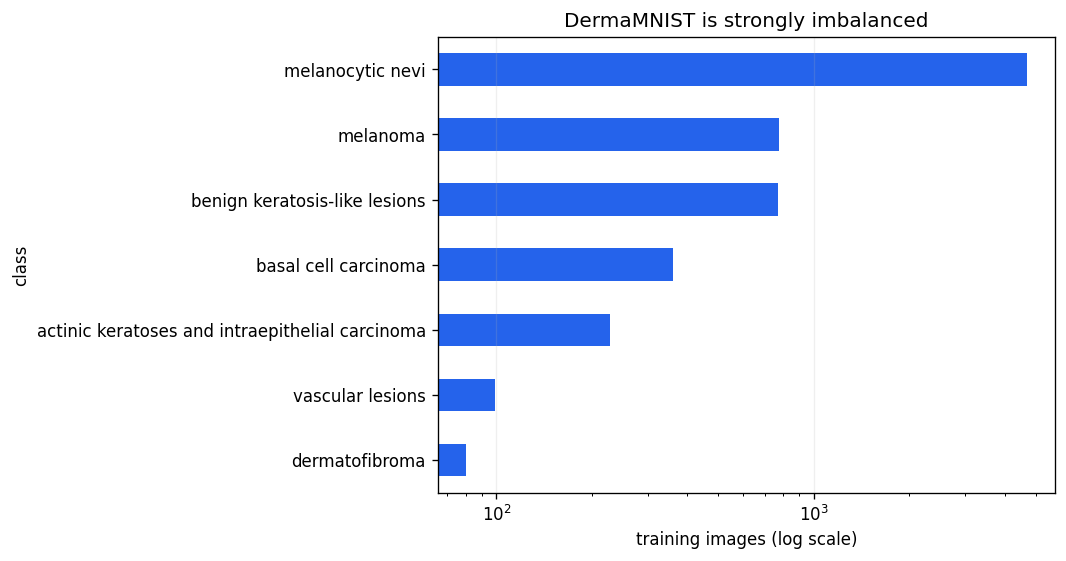

In [ ]:
# Phase 1: count every class separately in each official split.
class_counts = pd.DataFrame(
    {
        "class": CLASS_NAMES,
        "train": np.bincount(y_train, minlength=N_CLASSES),
        "validation": np.bincount(y_val, minlength=N_CLASSES),
    }
)
display(class_counts)

# Phase 2: plot training counts on a log scale so rare classes remain visible.
ax = class_counts.set_index("class")["train"].sort_values().plot.barh(
    figsize=(9, 4.8), color="#2563eb", logx=True
)
ax.set(xlabel="training images (log scale)", title="DermaMNIST is strongly imbalanced")
ax.grid(axis="x", alpha=0.2)
# Phase 3: keep the rarest classes legible without hiding the absolute counts.
plt.tight_layout()
plt.show()


The majority class makes up roughly two thirds of the data. A classifier that always predicts that class can therefore obtain seemingly respectable ordinary accuracy while having **zero recall for six classes**. Balanced accuracy averages recall across classes, so the same majority classifier receives $1/7\approx0.143$.

Macro F1 and macro AUPRC also give every class equal weight. This makes rare-class failures visible, but it creates wide uncertainty: the validation set contains very few examples of some classes. Macro estimates can move noticeably when only one or two rare cases change.


## 5. Inspect images without pretending to diagnose them

We draw two fixed training examples from each class. At $28\times28$, colour, broad borders, and gross texture remain visible, but fine dermatoscopic structures are lost. The montage helps us understand the tensor; it is not a diagnostic exercise and the labels are not an invitation to infer clinical criteria from compressed thumbnails.


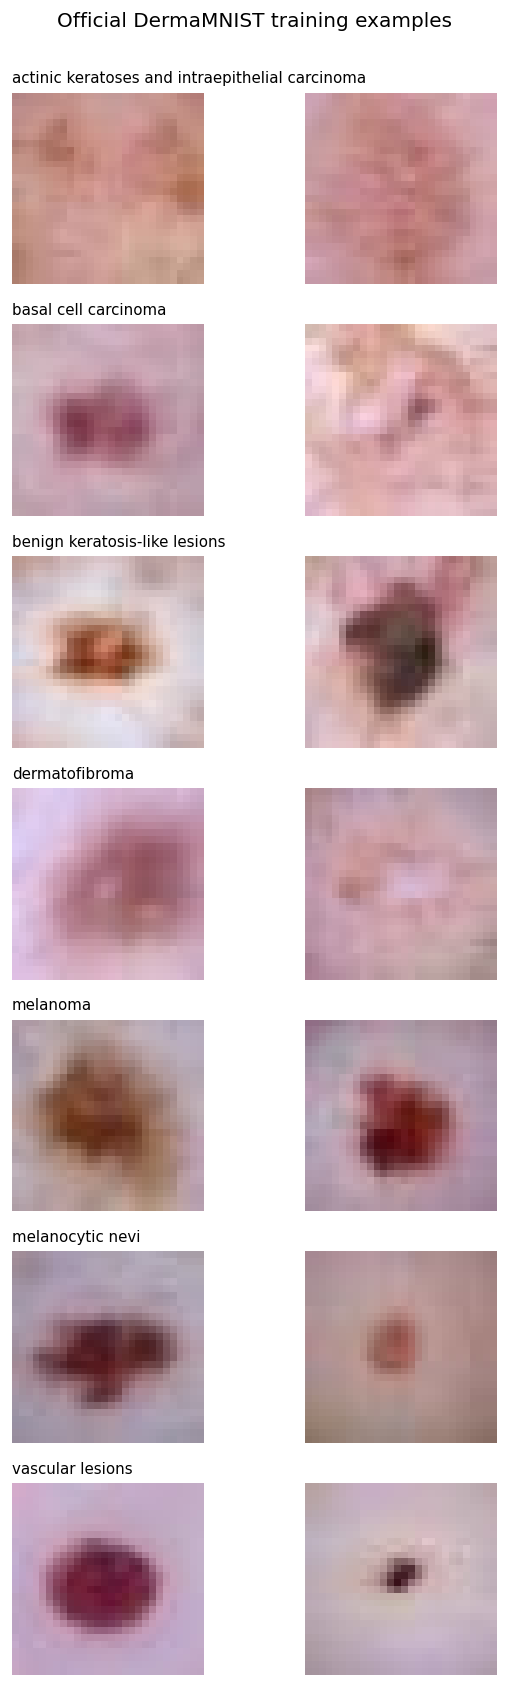

In [ ]:
# Phase 1: select examples reproducibly within each class.
rng = np.random.default_rng(SEED)
selected = [
    rng.choice(np.flatnonzero(y_train == class_id), size=2, replace=False)
    for class_id in range(N_CLASSES)
]

# Phase 2: place one class per row so label imbalance does not dominate the display.
fig, axes = plt.subplots(N_CLASSES, 2, figsize=(5.5, 14))
for class_id, image_ids in enumerate(selected):
    for column, image_id in enumerate(image_ids):
        axes[class_id, column].imshow(X_train[image_id])
        axes[class_id, column].axis("off")
        if column == 0:
            axes[class_id, column].set_title(CLASS_NAMES[class_id], fontsize=9, loc="left")
# Phase 3: state provenance directly in the figure title.
fig.suptitle("Official DermaMNIST training examples", y=1.001)
plt.tight_layout()
plt.show()


## 6. Protect the train–validation–test boundary

The official partitions have different jobs:

- **Train:** estimate feature means, PCA components, logistic coefficients, neural weights, and class weights.
- **Validation:** choose logistic regularization and neural early-stopping epochs.
- **Test:** estimate final performance once the complete pipeline is frozen.

We select models using **validation macro AUPRC** because it emphasizes performance across all seven one-vs-rest tasks and is sensitive to rare-class precision. Other defensible choices exist, but the choice must be made before test inspection.

Unlike a binary alert, this seven-class tutorial does not choose a single sensitivity threshold. The predicted class is `argmax`: the class with the largest probability. AUROC and AUPRC are computed one class versus all others and then macro-averaged. Test labels never determine a threshold, epoch, or regularization value.


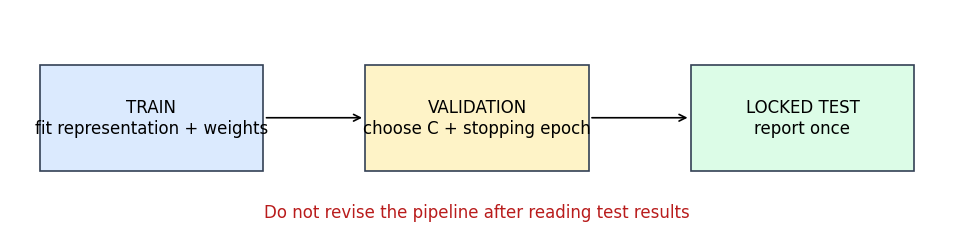

In [ ]:
# A visual reminder that information flows forward only.
fig, ax = plt.subplots(figsize=(10, 2.3))
ax.axis("off")
boxes = [
    (0.03, "TRAIN\nfit representation + weights", "#dbeafe"),
    (0.38, "VALIDATION\nchoose C + stopping epoch", "#fef3c7"),
    (0.73, "LOCKED TEST\nreport once", "#dcfce7"),
]
# Phase 1: draw three partitions with their non-interchangeable roles.
for x, label, colour in boxes:
    ax.add_patch(plt.Rectangle((x, 0.25), 0.24, 0.5, facecolor=colour, edgecolor="#334155"))
    ax.text(x + 0.12, 0.5, label, ha="center", va="center")
# Phase 2: arrows encode permitted forward information flow.
ax.annotate("", xy=(0.38, 0.5), xytext=(0.27, 0.5), arrowprops={"arrowstyle": "->"})
ax.annotate("", xy=(0.73, 0.5), xytext=(0.62, 0.5), arrowprops={"arrowstyle": "->"})
# Phase 3: make the prohibited direction explicit.
ax.text(0.5, 0.03, "Do not revise the pipeline after reading test results", ha="center", color="#b91c1c")
plt.show()


## 7. Define multiclass metrics once

Balanced accuracy and macro F1 use the `argmax` class. For ranking metrics, a seven-class problem becomes seven one-vs-rest questions. For example, melanoma is positive in one question and every other category is negative. We calculate an AUROC and AUPRC for each question, then average the seven values equally.

Macro AUROC can be high even when the final classifier is only moderately useful. Each one-vs-rest negative set is large, and ranking can be reasonable without producing precise rare-class predictions. Macro AUPRC starts from the average one-vs-rest prevalence, which equals $1/7$ when averaged across all classes, and is often more revealing here.

Multiclass log loss evaluates the full probability vector and penalizes confident wrong predictions. Lower is better. It complements, rather than replaces, discrimination metrics.


In [ ]:
def multiclass_metrics(labels, probabilities):
    '''Return complementary argmax, ranking, and probability metrics.'''
    # Phase 1: argmax converts seven probabilities into one predicted class.
    predictions = probabilities.argmax(axis=1)
    one_hot_labels = label_binarize(labels, classes=np.arange(N_CLASSES))
    # Phase 2: one-vs-rest metrics are calculated per class and macro-averaged.
    return {
        "balanced_accuracy": balanced_accuracy_score(labels, predictions),
        "macro_F1": f1_score(labels, predictions, average="macro", zero_division=0),
        "macro_AUROC": roc_auc_score(
            one_hot_labels, probabilities, average="macro", multi_class="ovr"
        ),
        "macro_AUPRC": average_precision_score(
            one_hot_labels, probabilities, average="macro"
        ),
        # Phase 3: log loss uses all seven probabilities and rewards calibration.
        "log_loss": log_loss(labels, probabilities, labels=np.arange(N_CLASSES)),
    }


def validation_macro_auprc(labels, probabilities):
    return multiclass_metrics(labels, probabilities)["macro_AUPRC"]


## 8. Model 0: the training class prior

The weakest model assigns every image the seven class fractions observed in training. Its argmax is always the majority class. It is valuable because it reveals how much performance comes from prevalence alone.

Its balanced accuracy is $1/7$, macro AUROC is 0.5, and macro AUPRC is $1/7$. Log loss is not meaningless: assigning realistic training priors is less overconfident than assigning probability one to the majority class.


In [ ]:
# Phase 1: estimate seven probabilities from training labels only.
training_priors = np.bincount(y_train, minlength=N_CLASSES) / len(y_train)
# Phase 2: tile the same vector for every validation and test image.
validation_probabilities = {
    "Class prior": np.tile(training_priors, (len(y_val), 1))
}
test_probabilities = {
    "Class prior": np.tile(training_priors, (len(y_test), 1))
}
# Phase 3: confirm that every probability vector is valid.
assert np.allclose(validation_probabilities["Class prior"].sum(axis=1), 1.0)
print("Training class priors:", np.round(training_priors, 3))


Training class priors: [0.033 0.051 0.11  0.011 0.111 0.67  0.014]


## 9. Model 1: coarse global colour/texture logistic regression

We compress each image into seven values: the mean and standard deviation of red, green, and blue pixels, plus overall intensity variation. Means summarize global colour. Standard deviations and total intensity variation are crude texture/contrast measures. They do not capture where a lesion sits, whether a border is irregular, or how local structures are arranged.

Multinomial logistic regression combines the standardized features linearly to produce seven logits followed by a softmax. We try three regularization strengths and select the one with highest validation macro AUPRC. The scaler is refitted inside each training-only pipeline; no validation feature statistic is learned.


In [ ]:
GLOBAL_FEATURE_NAMES = [
    "red_mean", "green_mean", "blue_mean",
    "red_sd", "green_sd", "blue_sd", "overall_intensity_sd",
]


def coarse_global_features(images):
    '''Compress RGB images to seven global colour/contrast summaries.'''
    # Phase 1: summarize each colour channel independently over the 28x28 grid.
    channel_means = images.mean(axis=(1, 2))
    channel_sds = images.std(axis=(1, 2))
    # Phase 2: retain one crude global texture/contrast statistic.
    overall_sd = images.mean(axis=3).std(axis=(1, 2), keepdims=False)[:, None]
    # Phase 3: concatenate to a conventional [images, features] table.
    return np.column_stack([channel_means, channel_sds, overall_sd])


global_train = coarse_global_features(X_train)
global_val = coarse_global_features(X_val)
global_test = coarse_global_features(X_test)

global_candidates = {}
for C in [0.03, 0.10, 0.30]:
    model = make_pipeline(
        StandardScaler(),
        LogisticRegression(
            C=C, max_iter=1_000, class_weight="balanced", random_state=SEED
        ),
    )
    model.fit(global_train, y_train)
    global_candidates[C] = model

# Selection uses validation labels; test labels remain untouched.
global_validation_scores = {
    C: validation_macro_auprc(y_val, model.predict_proba(global_val))
    for C, model in global_candidates.items()
}
selected_global_C = max(global_validation_scores, key=global_validation_scores.get)
global_model = global_candidates[selected_global_C]
validation_probabilities["Global logistic"] = global_model.predict_proba(global_val)
test_probabilities["Global logistic"] = global_model.predict_proba(global_test)

print("Validation macro AUPRC by C:", {C: round(v, 3) for C, v in global_validation_scores.items()})
print("Selected global-feature C:", selected_global_C)


Validation macro AUPRC by C: {0.03: 0.303, 0.1: 0.316, 0.3: 0.32}
Selected global-feature C: 0.3


This model is intentionally coarse. If it improves substantially over the prior, colour and contrast alone contain dataset-specific signal. That signal is not necessarily a clinically valid lesion representation: acquisition conditions, rulers, colour charts, cropping, or source differences can also affect global summaries.

Coefficients describe conditional associations in this fitted benchmark model. They should not be translated into statements such as “more red causes melanoma.”


## 10. Model 2: regularized logistic regression on flattened pixels

Flattening creates 2,352 ordered inputs: 28 rows × 28 columns × 3 channels. A full pixel logistic model is still linear, but it can assign a different weight to each location and colour.

To keep CPU runtime small and reduce collinearity, we fit a **training-only 64-component PCA** before logistic regression. PCA and logistic regression are both linear transformations, so the complete decision remains linear in the original flattened pixels. The PCA components are not labels or hand-engineered clinical features; they summarize directions of greatest training-image variation. `whiten=True` puts component scores on comparable scales.

We fix 64 components before looking at validation results, then choose logistic regularization on validation macro AUPRC. The test set never fits centring, PCA, or coefficients.


In [ ]:
# Phase 1: flatten RGB grids while retaining a consistent pixel/channel order.
pixel_train = X_train.reshape(len(X_train), -1)
pixel_val = X_val.reshape(len(X_val), -1)
pixel_test = X_test.reshape(len(X_test), -1)

# Phase 2: fit a linear training-only compression once, then freeze it.
pixel_centrer = StandardScaler(with_std=False)
centred_train = pixel_centrer.fit_transform(pixel_train)
centred_val = pixel_centrer.transform(pixel_val)
centred_test = pixel_centrer.transform(pixel_test)
pixel_pca = PCA(
    n_components=64, whiten=True, svd_solver="randomized", random_state=SEED
)
pixel_train_64 = pixel_pca.fit_transform(centred_train)
pixel_val_64 = pixel_pca.transform(centred_val)
pixel_test_64 = pixel_pca.transform(centred_test)

# Phase 3: choose only the regularization value using validation macro AUPRC.
pixel_candidates = {}
for C in [0.03, 0.10, 0.30]:
    model = LogisticRegression(
        C=C, max_iter=1_000, class_weight="balanced", random_state=SEED
    )
    model.fit(pixel_train_64, y_train)
    pixel_candidates[C] = model

pixel_validation_scores = {
    C: validation_macro_auprc(y_val, model.predict_proba(pixel_val_64))
    for C, model in pixel_candidates.items()
}
selected_pixel_C = max(pixel_validation_scores, key=pixel_validation_scores.get)
pixel_model = pixel_candidates[selected_pixel_C]
validation_probabilities["Pixel logistic"] = pixel_model.predict_proba(pixel_val_64)
test_probabilities["Pixel logistic"] = pixel_model.predict_proba(pixel_test_64)

print(f"PCA variance retained: {pixel_pca.explained_variance_ratio_.sum():.1%}")
print("Validation macro AUPRC by C:", {C: round(v, 3) for C, v in pixel_validation_scores.items()})
print("Selected pixel-model C:", selected_pixel_C)


PCA variance retained: 97.2%
Validation macro AUPRC by C: {0.03: 0.334, 0.1: 0.327, 0.3: 0.325}
Selected pixel-model C: 0.03


Pixel logistic regression uses more spatial information than the global model, but “more information” is not automatically “better information.” Alignment and acquisition artefacts can create location-specific associations. PCA also prioritizes common variation, which may underrepresent a rare but discriminative pattern. The comparison is empirical, not guaranteed to be monotonic.


## 11. Prepare neural tensors without leakage

PyTorch convolution expects `[batch, channel, height, width]`, while the package stores `[image, height, width, channel]`. We transpose the axes after normalizing each RGB channel using training means and standard deviations only.

The loss uses class weights proportional to inverse frequency raised to 0.65. This is milder than full inverse-frequency weighting: it asks the network to pay more attention to rare classes without letting a handful of rare samples dominate every gradient. The exponent is fixed before model comparison. Weighting changes the optimized objective and can affect calibration, which is why log loss remains in the final table.


In [ ]:
# Phase 1: estimate per-channel normalization from training pixels only.
training_rgb_mean = X_train.mean(axis=(0, 1, 2))
training_rgb_sd = X_train.std(axis=(0, 1, 2))


def neural_tensor(images):
    '''Normalize with frozen training statistics and transpose to [N,C,H,W].'''
    normalized = (images - training_rgb_mean) / training_rgb_sd
    return np.transpose(normalized.astype(np.float32), (0, 3, 1, 2))


X_train_nn = neural_tensor(X_train)
X_val_nn = neural_tensor(X_val)
X_test_nn = neural_tensor(X_test)

# Phase 2: derive a moderate rare-class weight from training counts only.
training_counts = np.bincount(y_train, minlength=N_CLASSES)
class_weights = (training_counts.max() / training_counts) ** 0.65
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32, device=DEVICE)

# Phase 3: create the shared training dataset; loaders are seeded per model.
neural_training_data = TensorDataset(
    torch.from_numpy(X_train_nn), torch.from_numpy(y_train)
)
print("Neural input shape:", X_train_nn.shape)
print("Training RGB mean:", np.round(training_rgb_mean, 3))
print("Class weights:", np.round(class_weights, 2))


Neural input shape: (7007, 3, 28, 28)
Training RGB mean: [0.764 0.537 0.561]
Class weights: [ 7.14  5.32  3.24 14.11  3.21  1.   12.28]


## 12. Models 3 and 4: MLP versus CNN

The MLP flattens the image, then learns nonlinear combinations through two hidden layers. It can represent interactions—for example, a pattern involving red values in two different locations—but it must learn spatial regularities from scratch.

The CNN uses shared $3\times3$ filters. A filter learned in one part of an image is reused elsewhere. Pooling reduces resolution; deeper filters combine earlier local responses; global average pooling summarizes each final feature map. This inductive bias usually suits images better and uses far fewer location-specific connections than an equivalently wide MLP.

Both output seven **logits**. `CrossEntropyLoss` applies the softmax internally during training. We call `softmax` only during evaluation to obtain probabilities.


In [ ]:
class ImageMLP(nn.Module):
    '''A nonlinear model that deliberately flattens the spatial grid.'''

    def __init__(self):
        super().__init__()
        # Phase 1: map 2,352 standardized pixels to a compact hidden representation.
        self.network = nn.Sequential(
            nn.Flatten(),                         # [B,3,28,28] -> [B,2352]
            nn.Linear(3 * 28 * 28, 160),
            nn.ReLU(),
            nn.Dropout(0.35),
            nn.Linear(160, 64),
            nn.ReLU(),
            nn.Dropout(0.20),
            nn.Linear(64, N_CLASSES),             # -> [B,7] logits
        )

    def forward(self, images):
        # Phase 2: no softmax here; cross-entropy expects raw logits.
        return self.network(images)


class CompactCNN(nn.Module):
    '''A small RGB CNN with shared local filters.'''

    def __init__(self):
        super().__init__()
        # Phase 1: learn local filters while reducing 28x28 to 7x7.
        self.features = nn.Sequential(
            nn.Conv2d(3, 24, kernel_size=3, padding=1), # [B,3,28,28] -> [B,24,28,28]
            nn.BatchNorm2d(24),
            nn.ReLU(),
            nn.MaxPool2d(2),                           # -> [B,24,14,14]
            nn.Conv2d(24, 48, kernel_size=3, padding=1),
            nn.BatchNorm2d(48),
            nn.ReLU(),
            nn.MaxPool2d(2),                           # -> [B,48,7,7]
            nn.Conv2d(48, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),                   # -> [B,64,1,1]
        )
        # Phase 2: convert the learned 64-value representation to seven logits.
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Dropout(0.25), nn.Linear(64, N_CLASSES)
        )

    def forward(self, images):
        # Phase 3: keep representation learning and classification visibly separate.
        return self.classifier(self.features(images))


for name, model in [("MLP", ImageMLP()), ("Compact CNN", CompactCNN())]:
    print(f"{name:11s}: {sum(parameter.numel() for parameter in model.parameters()):,} parameters")


MLP        : 387,239 parameters
Compact CNN: 39,527 parameters


The CNN has a stronger image-specific assumption, not necessarily more parameters. Convolution shares weights across locations. The MLP's first layer alone contains hundreds of thousands of separate pixel connections.

We train both models with the same optimizer, batches, class weights, maximum 10 epochs, and validation-macro-AUPRC early stopping. Recreating the seeded loader inside the fitting function gives both models the same shuffle order. No test array enters the fitting function.


In [ ]:
@torch.no_grad()
def neural_probabilities(model, images, batch_size=256):
    '''Return seven-class softmax probabilities in memory-safe batches.'''
    # Phase 1: disable dropout/BatchNorm updates and gradient storage.
    model.eval()
    tensor = torch.from_numpy(images)
    outputs = []
    # Phase 2: move only one batch at a time to the selected device.
    for start in range(0, len(tensor), batch_size):
        batch = tensor[start : start + batch_size].to(DEVICE)
        outputs.append(torch.softmax(model(batch), dim=1).cpu().numpy())
    # Phase 3: restore original image order in one probability matrix.
    return np.concatenate(outputs)


def fit_neural_model(model, max_epochs=10, patience=3):
    '''Fit training images and restore the validation-best checkpoint.'''
    model = model.to(DEVICE)
    # Phase 1: recreate the seeded loader so architectures see the same shuffles.
    loader = DataLoader(
        neural_training_data,
        batch_size=256,
        shuffle=True,
        generator=torch.Generator().manual_seed(SEED),
    )
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-3)
    loss_function = nn.CrossEntropyLoss(weight=class_weights_tensor)

    best_score = -np.inf
    best_state = None
    stale_epochs = 0
    history = {"training_loss": [], "validation_macro_AUPRC": []}

    for epoch in range(max_epochs):
        # Phase 2: update parameters using training mini-batches only.
        model.train()
        losses = []
        for batch_images, batch_labels in loader:
            batch_images = batch_images.to(DEVICE)
            batch_labels = batch_labels.to(DEVICE)
            optimizer.zero_grad()
            loss = loss_function(model(batch_images), batch_labels)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
            optimizer.step()
            losses.append(float(loss.detach().cpu()))

        # Validation chooses the checkpoint; test labels remain inaccessible.
        val_probabilities = neural_probabilities(model, X_val_nn)
        val_score = validation_macro_auprc(y_val, val_probabilities)
        history["training_loss"].append(np.mean(losses))
        history["validation_macro_AUPRC"].append(val_score)

        if val_score > best_score + 1e-4:
            best_score = val_score
            best_state = copy.deepcopy(model.state_dict())
            stale_epochs = 0
        else:
            stale_epochs += 1
        if stale_epochs >= patience:
            break

    # Phase 3: restore the best validation epoch, not simply the final epoch.
    model.load_state_dict(best_state)
    return model, history, best_score


In [ ]:
trained_neural_models = {}
neural_histories = {}

# Phase 1: apply the identical training protocol to MLP and CNN.
for name, candidate in [("MLP", ImageMLP()), ("Compact CNN", CompactCNN())]:
    fitted, history, best_score = fit_neural_model(candidate)
    trained_neural_models[name] = fitted
    neural_histories[name] = history
    # Phase 2: store validation probabilities for transparent model selection records.
    validation_probabilities[name] = neural_probabilities(fitted, X_val_nn)
    # Phase 3: generate test probabilities only after the selected state is restored.
    test_probabilities[name] = neural_probabilities(fitted, X_test_nn)
    print(
        f"{name}: {len(history['training_loss'])} epochs; "
        f"best validation macro AUPRC={best_score:.3f}"
    )


MLP: 10 epochs; best validation macro AUPRC=0.412
Compact CNN: 10 epochs; best validation macro AUPRC=0.502


Learning curves answer two different questions. Training loss shows whether optimization fits the weighted objective. Validation macro AUPRC shows whether one-vs-rest ranking transfers across all seven classes. Training loss can continue falling while the validation curve stalls; that is why the final epoch is not automatically the deployed epoch.

Validation macro AUPRC is noisy because some classes have only a handful of examples. Early stopping reduces unnecessary overfitting but does not eliminate selection uncertainty.


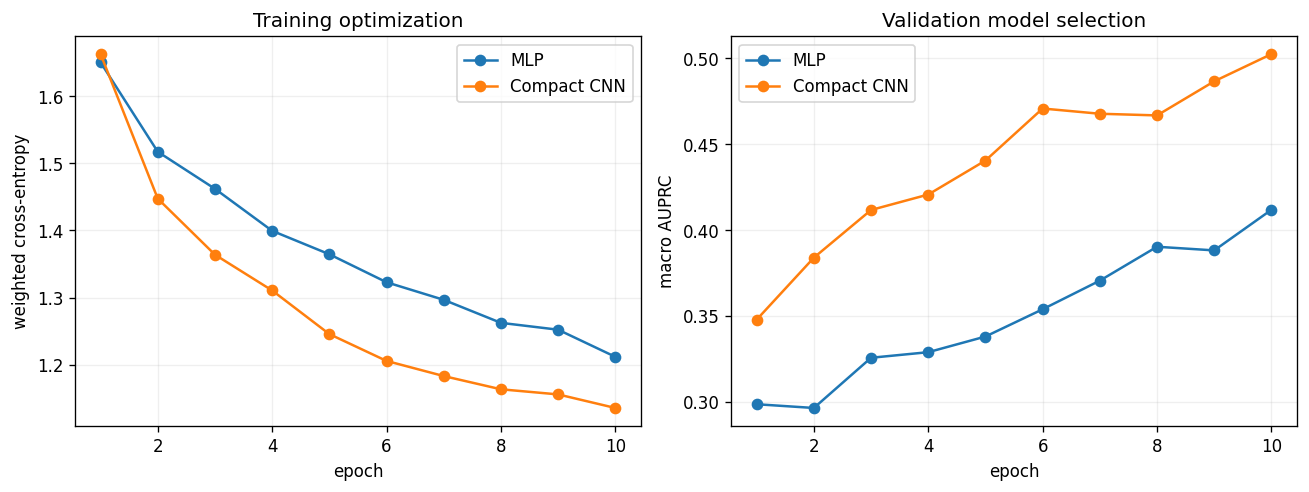

In [ ]:
# Phase 1: place optimization and held-out selection on separate axes.
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for name, history in neural_histories.items():
    epochs = np.arange(1, len(history["training_loss"]) + 1)
    axes[0].plot(epochs, history["training_loss"], marker="o", label=name)
    axes[1].plot(epochs, history["validation_macro_AUPRC"], marker="o", label=name)
# Phase 2: label metrics precisely; the left curve is not test performance.
axes[0].set(title="Training optimization", xlabel="epoch", ylabel="weighted cross-entropy")
axes[1].set(title="Validation model selection", xlabel="epoch", ylabel="macro AUPRC")
# Phase 3: use matching formatting for a fair visual comparison.
for axis in axes:
    axis.grid(alpha=0.2)
    axis.legend()
plt.tight_layout()
plt.show()


## 13. Final locked-test comparison

All feature preprocessing, logistic regularization, neural weights, and stopping epochs are now frozen. We can open the official test labels once.

No single number defines the winner. Balanced accuracy and macro F1 assess argmax classification; macro AUROC and AUPRC assess one-vs-rest ranking; log loss assesses the full probability vector. We expect a broad improvement from prior to learned image models and a further benefit from the CNN's spatial bias—but not a perfect staircase or near-perfect performance.


,model,balanced_accuracy,macro_F1,macro_AUROC,macro_AUPRC,log_loss
0,Class prior,0.143,0.115,0.500,0.143,1.133
1,Global logistic,0.436,0.320,0.817,0.337,1.457
2,Pixel logistic,0.480,0.347,0.843,0.366,1.301
3,MLP,0.482,0.429,0.885,0.411,0.881
4,Compact CNN,0.483,0.423,0.896,0.463,0.841


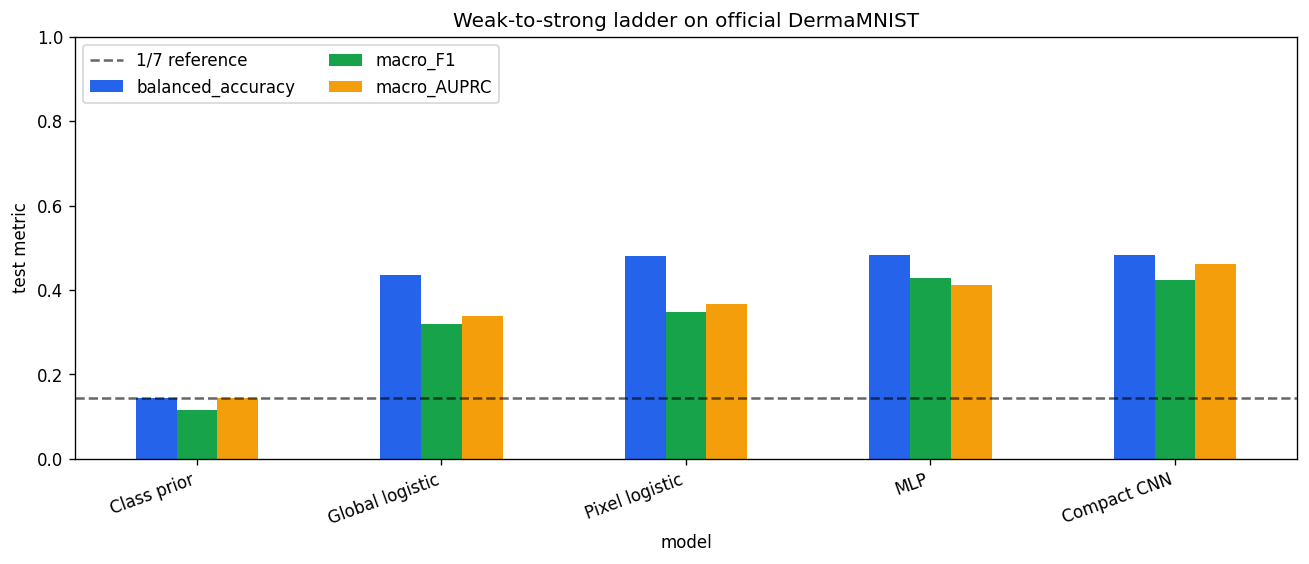

Macro AUPRC rises from 0.143 for the class prior to 0.463 for the CNN. Highest balanced accuracy is 0.483 (Compact CNN). These are useful but clearly non-perfect internal results.


In [ ]:
MODEL_ORDER = ["Class prior", "Global logistic", "Pixel logistic", "MLP", "Compact CNN"]

# Phase 1: evaluate every frozen probability matrix with one shared function.
test_results = pd.DataFrame(
    [
        {"model": name, **multiclass_metrics(y_test, test_probabilities[name])}
        for name in MODEL_ORDER
    ]
)
display(
    test_results.style.format(
        {column: "{:.3f}" for column in test_results.columns if column != "model"}
    )
)

# Phase 2: compare the most imbalance-aware rank/classification metrics visually.
ax = test_results.set_index("model")[["balanced_accuracy", "macro_F1", "macro_AUPRC"]].plot.bar(
    figsize=(11, 4.8), color=["#2563eb", "#16a34a", "#f59e0b"]
)
ax.axhline(1 / N_CLASSES, color="black", linestyle="--", alpha=0.6, label="1/7 reference")
ax.set(ylim=(0, 1), ylabel="test metric", title="Weak-to-strong ladder on official DermaMNIST")
ax.legend(loc="upper left", ncol=2)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

# Phase 3: print immediate numerical interpretation rather than leaving a bare table.
prior_ap = test_results.loc[test_results.model == "Class prior", "macro_AUPRC"].iloc[0]
cnn_ap = test_results.loc[test_results.model == "Compact CNN", "macro_AUPRC"].iloc[0]
best_balanced = test_results.loc[test_results.balanced_accuracy.idxmax()]
print(
    f"Macro AUPRC rises from {prior_ap:.3f} for the class prior to {cnn_ap:.3f} "
    f"for the CNN. Highest balanced accuracy is {best_balanced.balanced_accuracy:.3f} "
    f"({best_balanced.model}). These are useful but clearly non-perfect internal results."
)


### How to interpret these results

The central result is improvement without fantasy. The class prior cannot distinguish images. Coarse global summaries add dataset signal. Pixel logistic regression uses more of the image while remaining linear. The MLP adds nonlinearity, and the CNN adds a representation designed for local spatial structure. The CNN should be strongest on several macro metrics, but its results remain far from 1.0.

A perfectly monotonic order is not required. The global model may beat the pixel model on a metric because colour summaries are data-efficient. Pixel PCA may discard low-variance discriminative detail. The MLP may improve macro AUPRC but not balanced accuracy because its probability ranking improves without changing enough argmax decisions. Differences of a few points can easily reflect sampling and training variation.

Macro AUROC may look much higher than balanced accuracy or macro AUPRC. That is not contradictory. One-vs-rest AUROC asks whether positives tend to rank above a large negative set; it does not require precise probabilities or a correct seven-way argmax. In an imbalanced medical dataset, reporting only AUROC would create an overly flattering impression.

These are internal benchmark results. They do not show performance for a new hospital, device, skin tone distribution, patient population, or clinical workflow.


## 14. Per-class results reveal what macro averages hide

Macro averages weight all classes equally but do not show which classes fail. We calculate each class's support, argmax recall, and one-vs-rest AUPRC for the CNN. A class with only a few dozen test examples can have an unstable estimate; one error changes recall considerably.


In [ ]:
cnn_probabilities = test_probabilities["Compact CNN"]
cnn_predictions = cnn_probabilities.argmax(axis=1)
one_hot_test = label_binarize(y_test, classes=np.arange(N_CLASSES))

# Phase 1: compute class-specific recalls from the multiclass confusion matrix.
matrix = confusion_matrix(y_test, cnn_predictions, labels=np.arange(N_CLASSES))
per_class_recall = np.diag(matrix) / matrix.sum(axis=1)
# Phase 2: calculate one-vs-rest AP separately instead of averaging immediately.
per_class_ap = average_precision_score(
    one_hot_test, cnn_probabilities, average=None
)
per_class_results = pd.DataFrame(
    {
        "class": CLASS_NAMES,
        "test_support": np.bincount(y_test, minlength=N_CLASSES),
        "argmax_recall": per_class_recall,
        "one_vs_rest_AUPRC": per_class_ap,
    }
)
# Phase 3: display support beside performance so rare-class uncertainty is visible.
display(per_class_results.style.format({"argmax_recall": "{:.3f}", "one_vs_rest_AUPRC": "{:.3f}"}))


,class,test_support,argmax_recall,one_vs_rest_AUPRC
0,actinic keratoses and intraepithelial carcinoma,66,0.576,0.359
1,basal cell carcinoma,103,0.553,0.429
2,benign keratosis-like lesions,220,0.309,0.466
3,dermatofibroma,23,0.043,0.151
4,melanoma,223,0.305,0.437
5,melanocytic nevi,1341,0.870,0.935
6,vascular lesions,29,0.724,0.461


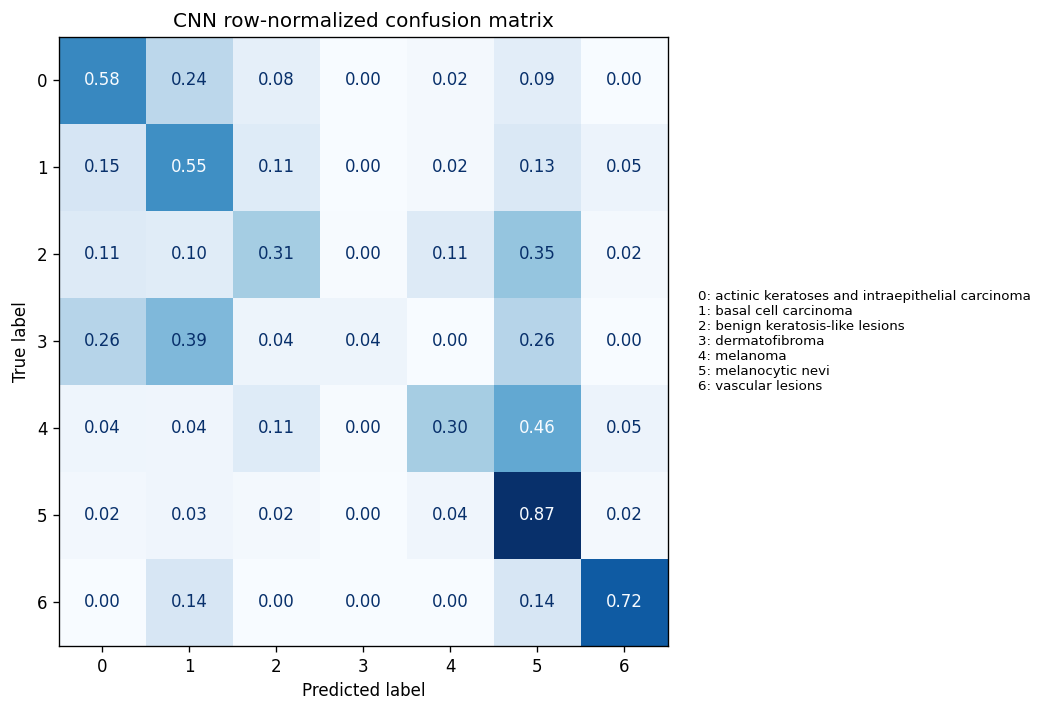

In [ ]:
# Phase 1: normalize rows so each true class contributes equally to the colour scale.
row_normalized = matrix / matrix.sum(axis=1, keepdims=True)
fig, ax = plt.subplots(figsize=(8, 7))
# Phase 2: show confusions using abbreviated numeric class IDs for readability.
display_object = ConfusionMatrixDisplay(
    confusion_matrix=row_normalized,
    display_labels=np.arange(N_CLASSES),
)
display_object.plot(ax=ax, cmap="Blues", values_format=".2f", colorbar=False)
ax.set_title("CNN row-normalized confusion matrix")
# Phase 3: provide the ID-to-name map beside the matrix.
legend_text = "\n".join(f"{index}: {name}" for index, name in enumerate(CLASS_NAMES))
ax.text(1.05, 0.5, legend_text, transform=ax.transAxes, va="center", fontsize=8)
plt.tight_layout()
plt.show()


The confusion matrix is row-normalized, so a rare class has the same visual row weight as the majority class. This is useful for error pattern inspection but should always be shown with support counts. The matrix describes association on this split; it does not reveal why a model confused two diagnoses or whether the source label was correct.


## 15. Inspect feature maps carefully

A first-layer feature map shows where a learned filter responds for one image. It can diagnose dead filters or sensitivity to broad edges and colours. It is **not** a causal explanation, lesion segmentation, or proof that the network uses clinically valid evidence.


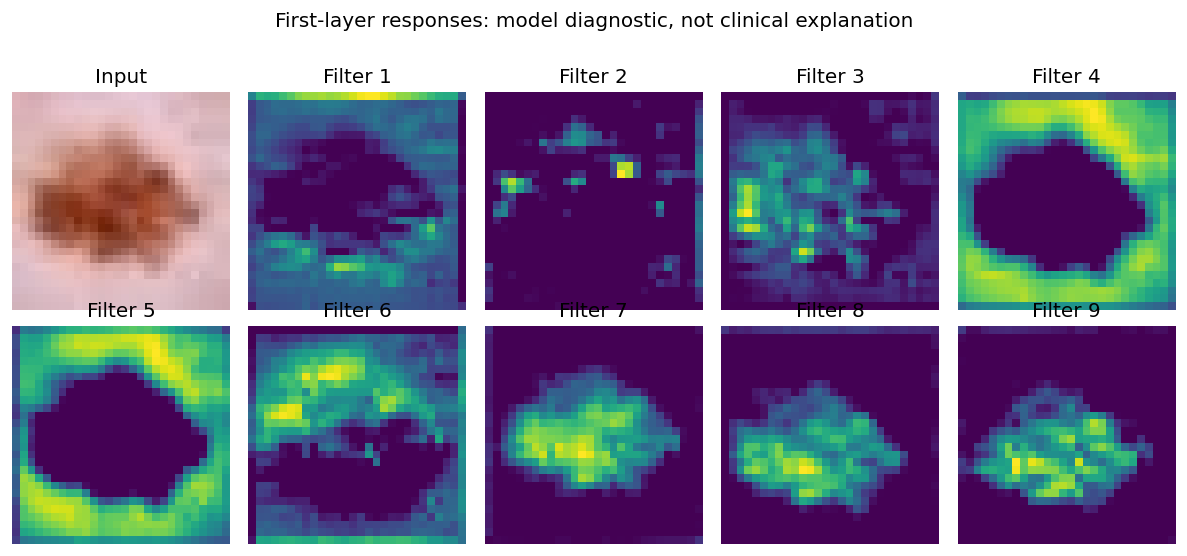

In [ ]:
# Phase 1: select the first correctly classified melanoma example by a fixed rule.
melanoma_id = 4
candidate_positions = np.flatnonzero((y_test == melanoma_id) & (cnn_predictions == melanoma_id))
example_position = int(candidate_positions[0]) if len(candidate_positions) else int(np.flatnonzero(y_test == melanoma_id)[0])
example_tensor = torch.from_numpy(X_test_nn[example_position : example_position + 1]).to(DEVICE)

# Phase 2: run only the first convolution and ReLU without storing gradients.
first_convolution = trained_neural_models["Compact CNN"].features[0]
with torch.no_grad():
    maps = torch.relu(first_convolution(example_tensor))[0].cpu().numpy()

# Phase 3: place the original image beside nine response maps.
fig, axes = plt.subplots(2, 5, figsize=(10, 4.5))
axes.ravel()[0].imshow(X_test[example_position])
axes.ravel()[0].set_title("Input")
axes.ravel()[0].axis("off")
for map_index, feature_map in enumerate(maps[:9], start=1):
    axes.ravel()[map_index].imshow(feature_map, cmap="viridis")
    axes.ravel()[map_index].set_title(f"Filter {map_index}")
    axes.ravel()[map_index].axis("off")
fig.suptitle("First-layer responses: model diagnostic, not clinical explanation", y=1.02)
plt.tight_layout()
plt.show()


## 16. From an internal benchmark to clinical evidence

A deployment study would need much more than a higher macro AUPRC:

**Intended use.** Define the user, patient population, acquisition process, decision point, comparator, and consequence of each error. “Classify skin lesions” is not precise enough.

**Data integrity.** Resolve patient- and lesion-level duplicates; audit label verification, device and site metadata, missingness, preprocessing, and temporal leakage. Split at the patient or lesion level when appropriate.

**External validation.** Evaluate independent institutions, devices, geographic regions, later time periods, and relevant demographic and skin-tone groups. Report uncertainty and calibration, not only discrimination.

**Human factors.** Study how clinicians or patients interpret scores, whether automation bias changes decisions, how uncertainty and abstention are displayed, and what happens when the model disagrees with a human.

**Prospective impact.** Compare against actual care, measure downstream biopsies, delays, false reassurance, workload, equity, and patient-centred outcomes. A retrospective label metric is not a clinical benefit.

**Governance and monitoring.** Establish ownership, update control, incident reporting, audit logs, subgroup monitoring, drift thresholds, pause criteria, and retirement processes.


## 17. Knowledge check and optional extensions

1. Why can the majority model have high ordinary accuracy but balanced accuracy of $1/7$?
2. What information is lost by the global features? What is lost by PCA?
3. Why is PCA plus logistic regression still linear in the original pixels?
4. Why can macro AUROC be high while macro AUPRC and balanced accuracy remain moderate?
5. Which quantities are learned on training data, and which choices use validation data?
6. Why would a patient- or lesion-level external split be more informative than this internal image split?

:::{dropdown} Optional coding extensions
- Repeat MLP and CNN training over five seeds and plot rank instability.
- Bootstrap test images for an introductory uncertainty interval, then explain why lesion clustering may require cluster bootstrap.
- Add training-only horizontal/vertical flips and compare validation macro AUPRC and log loss.
- Calibrate one frozen model using validation data and assess test log loss.
- Compare macro, weighted, and micro averages and explain whose performance each emphasizes.
- Add an abstention rule selected on validation data, then report coverage and selective risk on test.
:::


## 18. Take-home messages

- Build a ladder that changes one representational capability at a time.
- Use official data provenance and stop visibly when the intended dataset is unavailable.
- For imbalanced multiclass tasks, report balanced accuracy, macro F1, per-class results, macro ranking metrics, and probability quality—not accuracy or AUROC alone.
- PCA, scaling, regularization, neural weights, and stopping epochs must respect train/validation/test roles.
- A CNN's image-specific inductive bias can improve performance, but architecture alone does not guarantee a monotonic win.
- Moderate results with visible rare-class failures are more credible than near-perfect internal metrics.
- Internal benchmark performance is the beginning of evidence development, not permission for clinical use.


## References

1. Yang, J., Shi, R., Wei, D., et al. (2023). MedMNIST v2: A large-scale lightweight benchmark for 2D and 3D biomedical image classification. *Scientific Data, 10*, 41. <https://doi.org/10.1038/s41597-022-01721-8>
2. MedMNIST. *MedMNIST v2 documentation and dataset cards*. <https://medmnist.com/v2>
3. Tschandl, P., Rosendahl, C., & Kittler, H. (2018). The HAM10000 dataset: A large collection of multi-source dermatoscopic images of common pigmented skin lesions. *Scientific Data, 5*, 180161. <https://doi.org/10.1038/sdata.2018.161>
4. LeCun, Y., Bengio, Y., & Hinton, G. (2015). Deep learning. *Nature, 521*, 436–444. <https://doi.org/10.1038/nature14539>
5. Esteva, A., Kuprel, B., Novoa, R. A., et al. (2017). Dermatologist-level classification of skin cancer with deep neural networks. *Nature, 542*, 115–118. <https://doi.org/10.1038/nature21056>
6. Winkler, J. K., Fink, C., Toberer, F., et al. (2019). Association between surgical skin markings in dermoscopic images and diagnostic performance of a deep learning convolutional neural network for melanoma recognition. *JAMA Dermatology, 155*(10), 1135–1141. <https://doi.org/10.1001/jamadermatol.2019.1735>
7. Daneshjou, R., Vodrahalli, K., Novoa, R. A., et al. (2022). Disparities in dermatology AI performance on a diverse, curated clinical image set. *Science Advances, 8*(32), eabq6147. <https://doi.org/10.1126/sciadv.abq6147>
8. Collins, G. S., Moons, K. G. M., Dhiman, P., et al. (2024). TRIPOD+AI statement. *BMJ, 385*, e078378. <https://doi.org/10.1136/bmj-2023-078378>
